Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Total Original Closed Mask Area: 206064 pixels
Total Filtered Red Blob Area: 2845.0 pixels


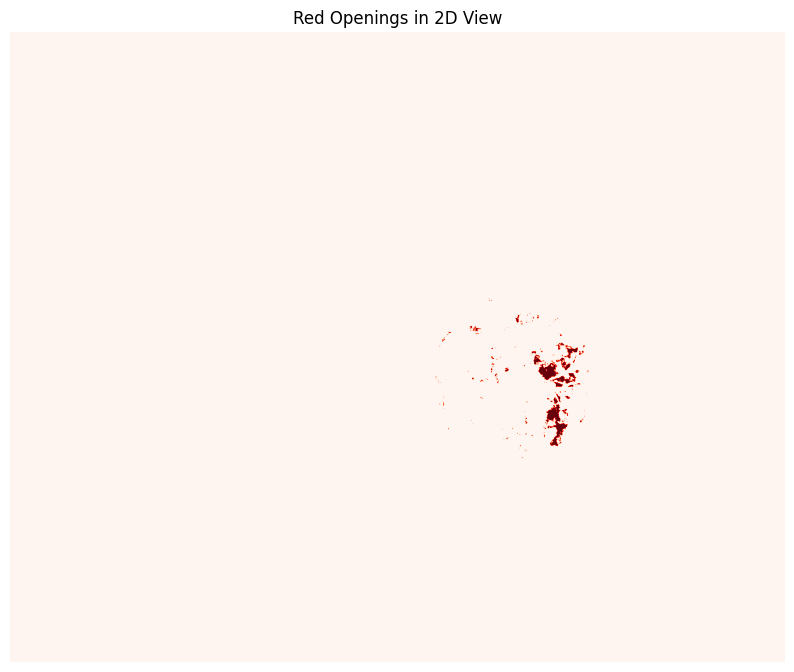

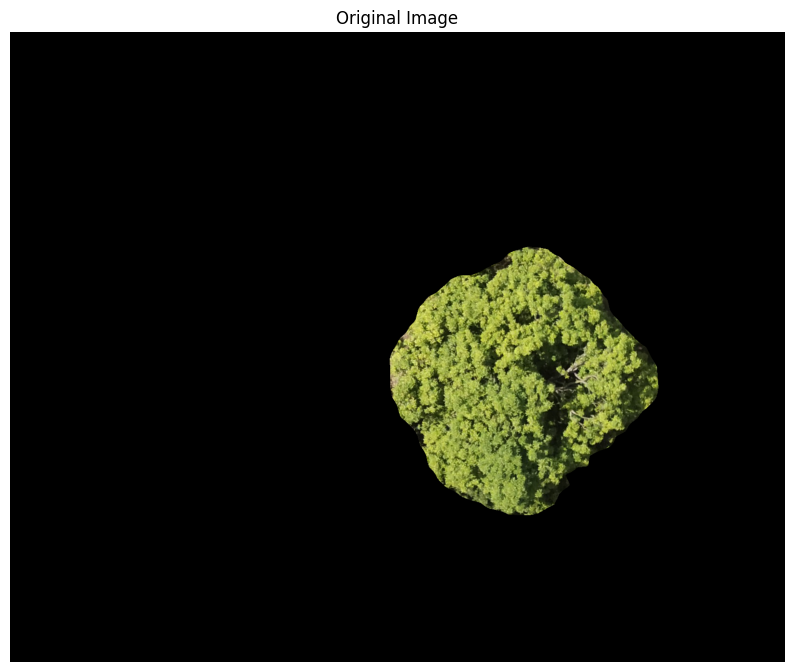

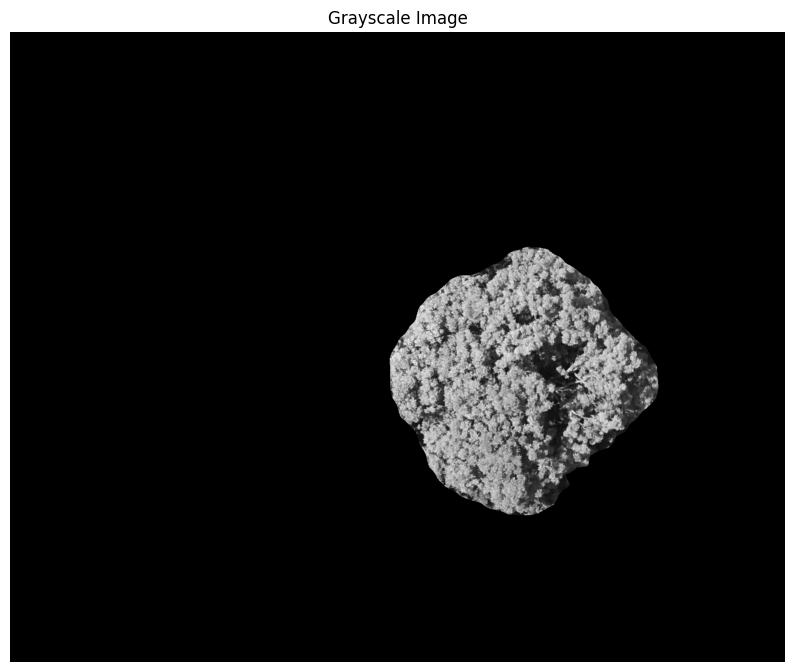

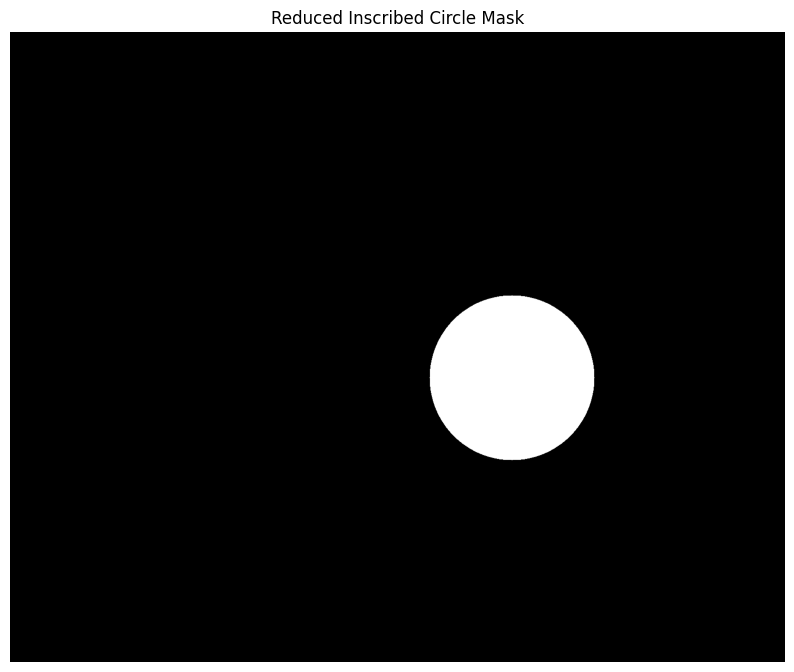

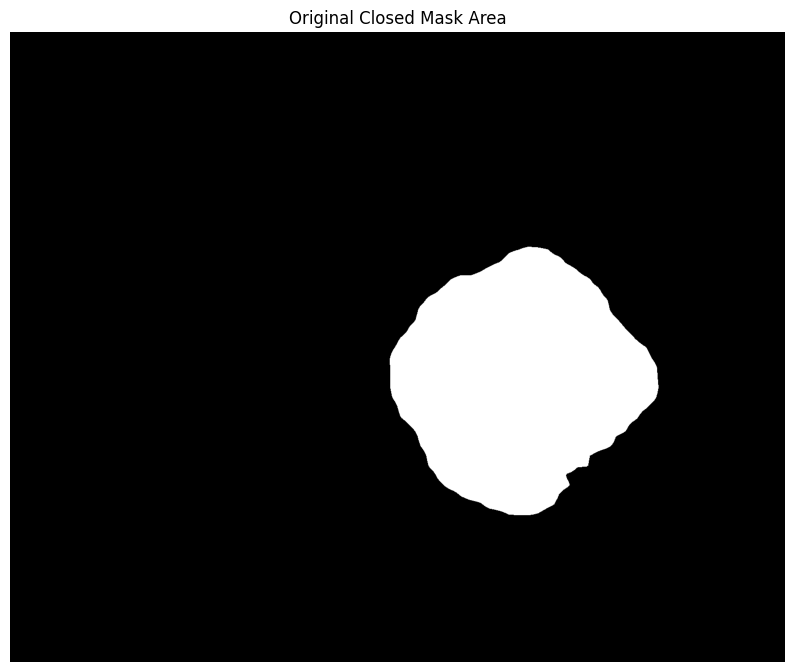

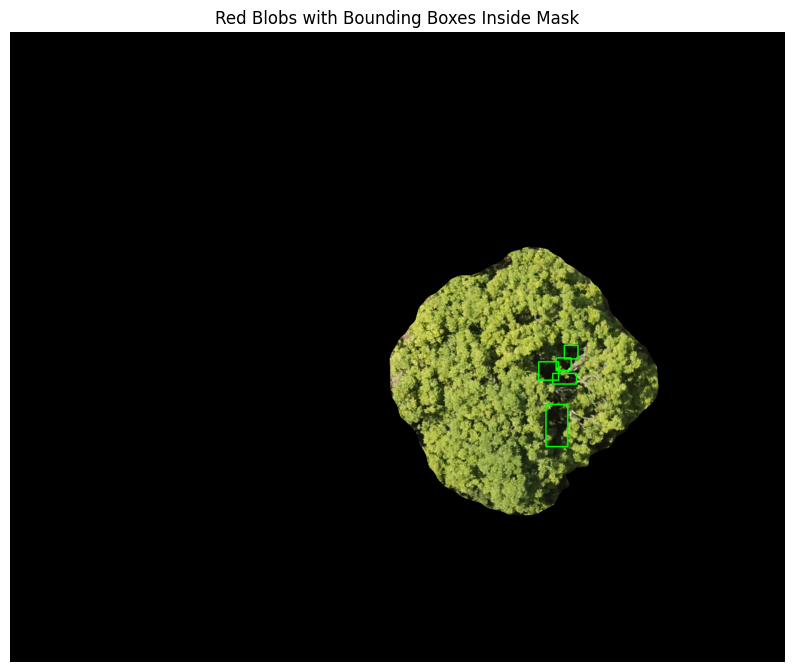

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import open3d as o3d
from scipy.ndimage import distance_transform_edt

# Load the image
image_path = "Images_To_Show_2/101FPLAN_DJI_0730.JPG_mask_0.png"  # Replace with actual file path
image = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Load in BGR format
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

# ----------------- Step 1: Extract Point Cloud Mask Pixels -----------------
y_indices, x_indices = np.where(gray > 0)  # Only non-zero values are part of the mask
total_mask_pixels = len(y_indices)

# ----------------- Step 2: Compute Largest Inscribed Circle -----------------
dist_transform = distance_transform_edt(gray > 0)
max_dist = np.max(dist_transform)
center_y, center_x = np.unravel_index(np.argmax(dist_transform), dist_transform.shape)
radius = int(max_dist)  # Convert to integer radius
reduced_radius = int(radius * 0.75)  # Reduce radius by 10%

# ----------------- Step 3: Create the Reduced Inscribed Circle Mask -----------------
circle_mask = np.zeros_like(gray, dtype=np.uint8)
cv2.circle(circle_mask, (center_x, center_y), reduced_radius, 255, thickness=-1)
reduced_inscribed_masked_image = cv2.bitwise_and(image, image, mask=circle_mask)

# ----------------- Step 4: Generate 3D Point Cloud -----------------
circle_y_indices, circle_x_indices = np.where(circle_mask > 0)
depth = (gray[circle_y_indices, circle_x_indices]) / 255.0
depth = depth * 100
points_3d = np.column_stack((circle_x_indices, circle_y_indices, depth))
sorted_indices = np.argsort(-depth)
points_3d = points_3d[sorted_indices]
colors = image[circle_y_indices, circle_x_indices] / 255.0
colors = colors[sorted_indices]

num_points_to_modify = int(len(points_3d) * 0.05)
exposed_mask = np.ones(len(points_3d), dtype=bool)
highest_depth_map = {}

for i, (x, y, z) in enumerate(points_3d):
    key = (int(x), int(y))
    if key in highest_depth_map and highest_depth_map[key] < z:
        exposed_mask[i] = False
    highest_depth_map[key] = z

exposed_indices = np.where(exposed_mask)[0]
num_to_change = min(num_points_to_modify, len(exposed_indices))
colors[exposed_indices[-num_to_change:], :] = [1.0, 0.0, 0.0]

# ----------------- Step 5: Compute Bounding Boxes for Red Blobs -----------------
red_pixel_mask = np.zeros_like(gray, dtype=np.uint8)
for i in exposed_indices[-num_to_change:]:
    x, y = int(points_3d[i, 0]), int(points_3d[i, 1])
    red_pixel_mask[y, x] = 255

contours, _ = cv2.findContours(red_pixel_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bounding_box_overlay = image.copy()
filtered_area = 0
for contour in contours:
    area = cv2.contourArea(contour)
    if area > 200:  # Apply minimum area threshold
        filtered_area += area
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(bounding_box_overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green bounding box

# Compute total area of the original closed mask
total_original_closed_mask_area = np.count_nonzero(gray > 0)

# Print area values
print(f"Total Original Closed Mask Area: {total_original_closed_mask_area} pixels")
print(f"Total Filtered Red Blob Area: {filtered_area} pixels")

# Convert to Open3D format
point_cloud = o3d.geometry.PointCloud()
point_cloud.points = o3d.utility.Vector3dVector(points_3d)
point_cloud.colors = o3d.utility.Vector3dVector(colors)

# Show 3D Point Cloud
o3d.visualization.draw_geometries([point_cloud], window_name="3D Point Cloud (Reduced Inscribed Circle)")

# ----------------- Step 6: Display Red Openings in 2D -----------------
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(red_pixel_mask, cmap='Reds')  # Show red pixel shape
ax.set_title("Red Openings in 2D View")
ax.axis("off")
plt.show()

# ----------------- Step 7: Display All Relevant Images -----------------
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image[..., ::-1])  # Convert BGR to RGB for display
ax.set_title("Original Image")
ax.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray, cmap="gray")
ax.set_title("Grayscale Image")
ax.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(circle_mask, cmap='gray')
ax.set_title("Reduced Inscribed Circle Mask")
ax.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray > 0, cmap='gray')
ax.set_title("Original Closed Mask Area")
ax.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(cv2.cvtColor(bounding_box_overlay, cv2.COLOR_BGR2RGB))
ax.set_title("Red Blobs with Bounding Boxes Inside Mask")
ax.axis("off")
plt.show()